In [ ]:
##############################################################################################################
########################################## Stage T=0 #########################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomWidth, RandomHeight, RandomZoom
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# print('x_train', x_train.shape)
# print('y_train', y_train.shape)

# x_train                         = x_train.reshape(x_train.shape[0], 32, 32, 3)
# x_test                          = x_test.reshape(x_test.shape[0], 32, 32, 3)
y_train                         = y_train.reshape(y_train.shape[0])
y_test                          = y_test.reshape(y_test.shape[0])
x_train                         = x_train.astype('float32')
x_test                          = x_test.astype('float32')
x_train /= 255.0
x_test  /= 255.0

# print('x_train', x_train.shape)
# print('y_train', y_train.shape)
# plt.figure()
# plt.imshow(x_train[4777])
# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim        = 100 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
batch_size        = 64
no_epochs         = 100
beta              = 1 # Lagrange Multiplier in Loss Function
AUTOTUNE = tf.data.AUTOTUNE
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test            = one_hot_encode(y_test)
# print('y_train', y_train)
# print('y_train', y_train.shape)
# print('y_test', y_test)
# print('y_test', y_test.shape)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomZoom(height_factor=(-0.4, 0.4), width_factor=(-0.4, 0.4))
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets
  # ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
  #             num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(x_train.shape[0])

  # Batch all datasets
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefecting on all datasets
  return ds.prefetch(buffer_size=AUTOTUNE)

#####################################################################################################################
# train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
# test_ds  = tf.data.Dataset.from_tensor_slices((x_test,y_test)).shuffle(x_test.shape[0]).batch(batch_size)
#####################################################################################################################
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_ds  = tf.data.Dataset.from_tensor_slices((x_test,y_test))
train_ds = prepare(train_ds, shuffle=True, augment=True)
test_ds = prepare(test_ds)
# # # =================================================================================================================
# # # ENCODER
# # # =================================================================================================================
# class Conv_Block(tf.keras.layers.Layer):
#     def __init__(self, filters, kernel_size, strides, drop):
#         super(Conv_Block, self).__init__()
#         self.conv_01       = Conv2D(filters=filters, kernel_size=kernel_size, strides=strides, padding='same', activation='relu')
#         self.conv_02       = Conv2D(filters=filters, kernel_size=kernel_size, strides=strides, padding='same', activation='relu')
#         self.BathchNorm_01 = BatchNormalization()
#         self.BathchNorm_02 = BatchNormalization()
#         self.dropout       = Dropout(drop)
#         self.maxpool       = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='same')

#     def call(self, x):
#         x1 = self.conv_01(x)
#         x2 = self.BathchNorm_01(x1)
#         x3 = self.conv_02(x2)
#         x4 = self.BathchNorm_02(x3)
#         x5 = self.maxpool(x4)
#         x6 = self.dropout(x5)
#         # x1 = self.conv_01(x)
#         # x2 = self.conv_02(x1)
#         # x3 = self.maxpool(x2)
#         # x4 = self.dropout(x3)
#         return x6

# class Encoder(tf.keras.layers.Layer):
#     def __init__(self, latent_dim):
#         super(Encoder, self).__init__()
#         self.conv_block1 = Conv_Block(32, 3, 2, 0.2)  #0.2
#         self.conv_block2 = Conv_Block(64, 3, 2, 0.3)  #0.3
#         self.conv_block3 = Conv_Block(128, 3, 2, 0.4) #0.4
#         self.flatten      = Flatten()
#         self.lineardense  = Dense(2*latent_dim, name='latent_mu')

#     def call(self, input1_enc_s1):
#         conv_b1 = self.conv_block1(input1_enc_s1)
#         conv_b2 = self.conv_block2(conv_b1)
#         conv_b3 = self.conv_block3(conv_b2)
#         flatten1_enc_s1   = self.flatten(conv_b3)
#         mu_logvar         = self.lineardense(flatten1_enc_s1)
#         return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # # =================================================================================================================
# # # DECODER
# # # =================================================================================================================
# class Decoder(tf.keras.layers.Layer):
#     def __init__(self):
#         super(Decoder, self).__init__()
#         self.dense_01     = Dense(128, activation='relu')
#         self.dense_04     = Dense(10)   # Softmax is added in Loss Function
#         self.BathchNorm   = BatchNormalization()
#         self.dropout      = Dropout(0.5) #0.5

#     def call(self, input1_dec_s1):
#         dense1_dec_s1     = self.dense_01(input1_dec_s1)
#         batchnorm         = self.BathchNorm(dense1_dec_s1)
#         dropout_01        = self.dropout(batchnorm)
#         dense4_dec_s1     = self.dense_04(dropout_01)
#         return dense4_dec_s1


# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv_01        = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_01     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_02     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_03        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.flatten        = Flatten()
        self.dense_10       = Dense(1024, activation='relu')
        self.dropout_01     = Dropout(0.1)
        self.dropout_02     = Dropout(0.2)
        self.dropout_03     = Dropout(0.3)
        self.lineardense    = Dense(2*latent_dim, name='latent_mu')
        self.BathchNorm_01  = BatchNormalization()
        self.BathchNorm_02  = BatchNormalization()

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        batch_01          = self.BathchNorm_01(conv1_enc_s1)
        maxpool1_enc_s1   = self.maxpool_01(batch_01)
        dropout1_enc_s1   = self.dropout_01(maxpool1_enc_s1)
        conv2_enc_s1      = self.conv_02(dropout1_enc_s1)
        batch_02          = self.BathchNorm_02(conv2_enc_s1)
        maxpool2_enc_s1   = self.maxpool_02(batch_02)
        dropout2_enc_s1   = self.dropout_02(maxpool2_enc_s1)
        conv3_enc_s1      = self.conv_03(dropout2_enc_s1)
        flatten1_enc_s1   = self.flatten(conv3_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout3_enc_s1   = self.dropout_03(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout3_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(128, activation='relu')
        self.BathchNorm_01  = BatchNormalization()
        self.dropout_01      = Dropout(0.4)
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        batch_01          = self.BathchNorm_01(dense1_dec_s1)
        dropout1_enc_s1   = self.dropout_01(batch_01)
        dense2_dec_s1     = self.dense_02(dropout1_enc_s1)
        return dense2_dec_s1



# # =================================================================================================================
# # VAE
# # =================================================================================================================
class VAE (tf.keras.Model):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder()

    def sampling (self, mu, logvar):
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu, logvar = self.encoder(input_vae)
        predictions = self.decoder(self.sampling(mu, logvar))
        return mu, logvar, predictions

# # =================================================================================================================
# # LOSS
# # =================================================================================================================

def Loss(mu, logvar, labels, predictions):  # prediction size:(batch, M, 10)
    cross_ent  = tf.nn.softmax_cross_entropy_with_logits(logits=predictions, labels=labels) #cross_ent size:(batch, M)
    logqx_u    = tf.math.reduce_mean(cross_ent)
    KL_loss    = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL       = (-1/2) * tf.math.reduce_mean(KL_loss)
    return D_KL + logqx_u, D_KL, logqx_u



# train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')

# test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_accuracy')


# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions = model(images)
        loss, D_KL, logqx_u = Loss(mu, logvar, labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_accuracy(labels, tf.nn.softmax(predictions))

# @tf.function
def test_step(model, images, labels):
    mu, logvar, predictions = model(images)
    test_accuracy(labels, tf.nn.softmax(predictions))


optimizer = tf.optimizers.Adam(learning_rate=1e-3)




# Create an instance of the model
model = VAE()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model, optimizer, images, labels)
        for test_images, test_labels in test_ds:
                test_step(model, test_images, test_labels)
        template = 'Epoch {}, train_accuracy: {}, test_accuracy: {}'
        print(template.format(epoch+1, train_accuracy.result()*100,
                              test_accuracy.result()*100))

Epoch 1, train_accuracy: 37.19199752807617, test_accuracy: 50.52000427246094
Epoch 2, train_accuracy: 44.718997955322266, test_accuracy: 53.8900032043457
Epoch 3, train_accuracy: 49.573333740234375, test_accuracy: 57.36333084106445
Epoch 4, train_accuracy: 52.95150375366211, test_accuracy: 59.657501220703125
Epoch 5, train_accuracy: 55.648399353027344, test_accuracy: 61.68400192260742
Epoch 6, train_accuracy: 57.862335205078125, test_accuracy: 63.31166458129883
Epoch 7, train_accuracy: 59.69200134277344, test_accuracy: 64.5057144165039
Epoch 8, train_accuracy: 61.2609977722168, test_accuracy: 65.68375396728516
Epoch 9, train_accuracy: 62.648223876953125, test_accuracy: 66.75555419921875
Epoch 10, train_accuracy: 63.86219787597656, test_accuracy: 67.51100158691406
Epoch 11, train_accuracy: 64.9769058227539, test_accuracy: 68.26545715332031
Epoch 12, train_accuracy: 65.9913330078125, test_accuracy: 68.84666442871094
Epoch 13, train_accuracy: 66.89446258544922, test_accuracy: 69.407691955

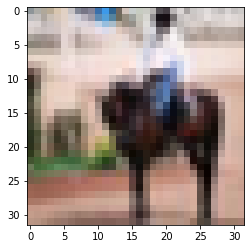

In [ ]:
plt.figure()
plt.imshow(x_train[11])

In [ ]:

# with np.printoptions(threshold=np.inf):
    print(y_train)

IndentationError: ignored

In [ ]:
##############################################################################################################
########################################## Stage T=1 #########################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomWidth, RandomHeight, RandomZoom
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# print('x_train', x_train.shape)
# print('x_test', x_test.shape)
# print('y_train', y_train.shape)
# print('y_test', y_test.shape)

# x_train                         = x_train.reshape(x_train.shape[0], 32, 32, 3)
# x_test                          = x_test.reshape(x_test.shape[0], 32, 32, 3)
# y_train                         = y_train.reshape(y_train.shape[0])
# y_test                          = y_test.reshape(y_test.shape[0])
# x_train                         = x_train.astype('float32')
# x_test                          = x_test.astype('float32')
# x_train /= 255
# x_test  /= 255
# x_test_original = x_test
# x_test_noisy    = x_test
# y_test_original = y_test
# y_test_noisy    = y_test


x_test_original, x_test_noisy, y_test_original, y_test_noisy           = train_test_split(x_test, y_test, test_size=1/2, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 32, 32, 3)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 32, 32, 3)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 32, 32, 3)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 32, 32, 3)

y_train_original                           = y_train_original.reshape(y_train_original.shape[0])
y_train_noisy                              = y_train_noisy.reshape(y_train_noisy.shape[0])
y_test_original                            = y_test_original.reshape(y_test_original.shape[0])
y_test_noisy                               = y_test_noisy.reshape(y_test_noisy.shape[0])

x_train_original                           = x_train_original.astype('float32')
x_train_noisy                              = x_train_noisy.astype('float32')
x_test_original                            = x_test_original.astype('float32')
x_test_noisy                               = x_test_noisy.astype('float32')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

# print('x_train_original', x_train_original.shape)
# print('x_train_noisy', x_train_noisy.shape)
# print('x_test_original', x_test_original.shape)
# print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.3
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)

  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss

x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
# x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777])

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777])

# print('x_test', x_test.shape)
# plt.figure()
# plt.imshow(x_test[4777])



# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim        = 100 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
batch_size        = 64
no_epochs         = 100
beta              = 1 # Lagrange Multiplier in Loss Function
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomZoom(height_factor=(-0.4, 0.4), width_factor=(-0.4, 0.4))
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets
  # ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
  #             num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(x_train.shape[0])

  # Batch all datasets
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefecting on all datasets
  return ds.prefetch(buffer_size=AUTOTUNE)


train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original))
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy))
train_ds         = prepare(train_ds, shuffle=True, augment=True)
test_original_ds = prepare(test_original_ds)
test_noisy_ds    = prepare(test_noisy_ds)



# train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
# test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
# test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).shuffle(x_val.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv_01        = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_01     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_02     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_03        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.flatten        = Flatten()
        self.dense_10       = Dense(1024, activation='relu')
        self.dropout_01     = Dropout(0.1)
        self.dropout_02     = Dropout(0.2)
        self.dropout_03     = Dropout(0.3)
        self.lineardense    = Dense(2*latent_dim, name='latent_mu')
        self.BathchNorm_01  = BatchNormalization()
        self.BathchNorm_02  = BatchNormalization()

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        batch_01          = self.BathchNorm_01(conv1_enc_s1)
        maxpool1_enc_s1   = self.maxpool_01(batch_01)
        dropout1_enc_s1   = self.dropout_01(maxpool1_enc_s1)
        conv2_enc_s1      = self.conv_02(dropout1_enc_s1)
        batch_02          = self.BathchNorm_02(conv2_enc_s1)
        maxpool2_enc_s1   = self.maxpool_02(batch_02)
        dropout2_enc_s1   = self.dropout_02(maxpool2_enc_s1)
        conv3_enc_s1      = self.conv_03(dropout2_enc_s1)
        flatten1_enc_s1   = self.flatten(conv3_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout3_enc_s1   = self.dropout_03(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout3_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(128, activation='relu')
        self.BathchNorm_01  = BatchNormalization()
        self.dropout_01      = Dropout(0.4)
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        batch_01          = self.BathchNorm_01(dense1_dec_s1)
        dropout1_enc_s1   = self.dropout_01(batch_01)
        dense2_dec_s1     = self.dense_02(dropout1_enc_s1)
        return dense2_dec_s1

# # =================================================================================================================
# # VAE
# # =================================================================================================================
class VAE (tf.keras.Model):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder()

    def sampling (self, mu, logvar):
        # mu         = tf.reshape(mu, [-1, latent_dim])
        # logvar     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu, logvar = self.encoder(input_vae)
        predictions = self.decoder(self.sampling(mu, logvar))
        return mu, logvar, predictions

# # =================================================================================================================
# # LOSS
# # =================================================================================================================

def Loss(mu, logvar, labels, predictions):  # prediction size:(batch, M, 10)

    cross_ent  = tf.nn.softmax_cross_entropy_with_logits(logits=predictions, labels=labels) #cross_ent size:(batch, M)
    logqx_u    = tf.math.reduce_mean(cross_ent)
    KL_loss    = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL       = (-1/2) * tf.math.reduce_mean(KL_loss)
    # print('D_KL', D_KL)
    # print('logqx_u', logqx_u)

    # global rate
    # global relevance
    # rate       += D_KL
    # relevance  += logqx_u
    # Total_loss = D_KL - beta * logqx_u
    # Total_loss =   D_KL - beta * logqx_u

    # print('labels',labels.shape)
    # print('predictions',predictions.shape)
    # print('cross_ent',cross_ent.shape)
    # print('logqx_u',logqx_u.shape)
    # print('KL_loss',KL_loss.shape)
    # print('D_KL',D_KL.shape)
          # qqq=0
    return D_KL + logqx_u, D_KL, logqx_u



# train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')

# test_loss = tf.keras.metrics.Mean(name='test_loss')
test_original_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy')
test_noisy_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy')

# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions = model(images)
        loss, D_KL, logqx_u = Loss(mu, logvar, labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss(loss)
    train_accuracy(labels, tf.nn.softmax(predictions)) # Predictions & Labels size:(batch,M,10)

# @tf.function
def test_original_step(model, images, labels):
    mu, logvar, predictions = model(images)
    # loss, D_KL, logqx_u = Loss(mu, logvar, labels, predictions)
    # print('D_KL', D_KL)
    # print('logqx_u', logqx_u)
    # test_loss(t_loss)
    test_original_accuracy(labels, tf.nn.softmax(predictions))

# @tf.function
def test_noisy_step(model, images, labels):
    mu, logvar, predictions = model(images)
    # t_loss = Loss(mu, logvar, labels, predictions)
    # test_loss(t_loss)
    test_noisy_accuracy(labels, tf.nn.softmax(predictions))

optimizer = tf.optimizers.Adam(learning_rate=1e-3)




# Create an instance of the model
model = VAE()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model, test_images, test_labels)
        template = 'Epoch {}, train_accuracy: {}, test_original_accuracy: {},  test_noisy_accuracy: {}'
        print(template.format(epoch+1, train_accuracy.result()*100,
                              test_original_accuracy.result()*100,
                              test_noisy_accuracy.result()*100))
        if epoch == 0:
          One_Free  = np.array([test_original_accuracy.result()*100])
          One_Noisy = np.array([test_noisy_accuracy.result()*100])
        else:
          One_Free  = np.concatenate((One_Free, np.array([test_original_accuracy.result()*100])), axis=0)
          One_Noisy = np.concatenate((One_Noisy, np.array([test_noisy_accuracy.result()*100])), axis=0)

Epoch 1, train_accuracy: 32.15999984741211, test_original_accuracy: 46.720001220703125,  test_noisy_accuracy: 41.65999984741211
Epoch 2, train_accuracy: 38.16600036621094, test_original_accuracy: 50.230003356933594,  test_noisy_accuracy: 43.40999984741211
Epoch 3, train_accuracy: 41.92599868774414, test_original_accuracy: 53.426666259765625,  test_noisy_accuracy: 45.68000030517578
Epoch 4, train_accuracy: 44.765499114990234, test_original_accuracy: 55.540000915527344,  test_noisy_accuracy: 47.334999084472656
Epoch 5, train_accuracy: 47.07040023803711, test_original_accuracy: 57.19199752807617,  test_noisy_accuracy: 48.407997131347656
Epoch 6, train_accuracy: 48.94633483886719, test_original_accuracy: 58.7599983215332,  test_noisy_accuracy: 49.41999816894531
Epoch 7, train_accuracy: 50.54285430908203, test_original_accuracy: 59.9571418762207,  test_noisy_accuracy: 50.160003662109375
Epoch 8, train_accuracy: 51.952247619628906, test_original_accuracy: 60.992496490478516,  test_noisy_accu

In [ ]:
##############################################################################################################
########################################## T=1 ###############################################################
##############################################################################################################
print('One_Free', tf.round(One_Free*1000)/1000)
print('One_Noisy', tf.round(One_Noisy*1000)/1000)

One_Free tf.Tensor(
[46.72  50.23  53.427 55.54  57.192 58.76  59.957 60.992 62.016 62.834
 63.444 64.013 64.554 65.011 65.295 65.693 66.    66.3   66.605 66.885
 67.126 67.272 67.503 67.688 67.874 68.065 68.239 68.389 68.533 68.671
 68.775 68.925 69.03  69.132 69.222 69.289 69.37  69.439 69.511 69.573
 69.63  69.701 69.76  69.814 69.845 69.881 69.924 69.989 70.035 70.059
 70.081 70.124 70.155 70.19  70.227 70.25  70.266 70.279 70.294 70.316
 70.341 70.36  70.371 70.385 70.399 70.41  70.423 70.447 70.464 70.479
 70.495 70.507 70.501 70.509 70.535 70.544 70.552 70.565 70.567 70.574
 70.586 70.6   70.599 70.615 70.621 70.632 70.636 70.639 70.639 70.644
 70.659 70.667 70.681 70.691 70.701 70.71  70.719 70.72  70.732 70.733], shape=(100,), dtype=float32)
One_Noisy tf.Tensor(
[41.66  43.41  45.68  47.335 48.408 49.42  50.16  50.948 51.524 52.052
 52.669 53.085 53.595 53.987 54.225 54.46  54.635 54.943 55.124 55.367
 55.532 55.664 55.861 56.002 56.142 56.234 56.404 56.524 56.674 56.793
 56.8

In [ ]:
##############################################################################################################
########################################## Stage T=2 #########################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomWidth, RandomHeight, RandomZoom
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test_original, x_test_noisy, y_test_original, y_test_noisy       = train_test_split(x_test, y_test, test_size=1/2, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 32, 32, 3)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 32, 32, 3)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 32, 32, 3)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 32, 32, 3)


y_train_original                           = y_train_original.reshape(y_train_original.shape[0])
y_train_noisy                              = y_train_noisy.reshape(y_train_noisy.shape[0])
y_test_original                            = y_test_original.reshape(y_test_original.shape[0])
y_test_noisy                               = y_test_noisy.reshape(y_test_noisy.shape[0])


x_train_original                           = x_train_original.astype('float32')
x_train_noisy                              = x_train_noisy.astype('float32')
x_test_original                            = x_test_original.astype('float32')
x_test_noisy                               = x_test_noisy.astype('float32')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

# print('x_train_original', x_train_original.shape)
# print('x_train_noisy', x_train_noisy.shape)
# print('x_test_original', x_test_original.shape)
# print('x_test_noisy', x_test_noisy.shape)


############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.3
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss


x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
# x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test_noisy', x_test_noisy.shape)
# plt.figure()
# plt.imshow(x_test_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_test_original', x_test_original.shape)
# plt.figure()
# plt.imshow(x_test_original[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 50 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 50
batch_size        = 64
no_epochs         = 100
beta_01           = 1 # Lagrange Multiplier in Loss Function
beta_02           = 1
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out

y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomZoom(height_factor=(-0.4, 0.4), width_factor=(-0.4, 0.4))
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets
  # ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
  #             num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(x_train.shape[0])

  # Batch all datasets
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefecting on all datasets
  return ds.prefetch(buffer_size=AUTOTUNE)


train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original))
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy))
train_ds         = prepare(train_ds, shuffle=True, augment=True)
test_original_ds = prepare(test_original_ds)
test_noisy_ds    = prepare(test_noisy_ds)


# train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
# test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
# test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # # =================================================================================================================
# # # ENCODER
# # # =================================================================================================================
# class Encoder(tf.keras.layers.Layer):
#     def __init__(self, latent_dim):
#         super(Encoder, self).__init__()
#         self.latent_dim   = latent_dim
#         self.BatchNorm_01 = BatchNormalization()
#         self.BatchNorm_02 = BatchNormalization()
#         self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
#         self.dropout_2    = Dropout(0.2)
#         self.dropout_3    = Dropout(0.3)
#         self.dropout_4    = Dropout(0.4)
#         self.conv_01      = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
#         self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.flatten      = Flatten()
#         self.dense_10     = Dense(1024, activation='relu')
#         self.dropout      = Dropout(0.4)
#         self.lineardense  = Dense(2*latent_dim, name='latent_mu')

#     def call(self, input1_enc_s1):
#         conv1_enc_s1      = self.conv_01(input1_enc_s1)
#         # print('conv1_enc_s1', conv1_enc_s1.shape)
#         Batch_01          = self.BatchNorm_01(conv1_enc_s1)
#         maxpool1_enc_s1   = self.maxpool(Batch_01)
#         conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
#         # print('conv2_enc_s1', conv2_enc_s1.shape)
#         Batch_02          = self.BatchNorm_02(conv2_enc_s1)
#         maxpool2_enc_s1   = self.maxpool(Batch_02)
#         flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
#         dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
#         dropout1_enc_s1   = self.dropout_4(dense1_enc_s1)
#         mu_logvar         = self.lineardense(dropout1_enc_s1)
#         return tf.split(mu_logvar, num_or_size_splits=2, axis=1)
# # # =================================================================================================================
# # # ENCODER
# # # =================================================================================================================
# class Encoder(tf.keras.layers.Layer):
#     def __init__(self, latent_dim):
#         super(Encoder, self).__init__()
#         self.latent_dim   = latent_dim
#         self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
#         self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.flatten      = Flatten()
#         self.dense_10     = Dense(1024, activation='relu')
#         self.dropout      = Dropout(0.4)
#         self.lineardense  = Dense(2*latent_dim, name='latent_mu')

#     def call(self, input1_enc_s1):
#         conv1_enc_s1      = self.conv_01(input1_enc_s1)
#         maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
#         conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
#         maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
#         flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
#         dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
#         dropout1_enc_s1   = self.dropout(dense1_enc_s1)
#         mu_logvar         = self.lineardense(dropout1_enc_s1)
#         return tf.split(mu_logvar, num_or_size_splits=2, axis=1)
# # # =================================================================================================================
# # # DECODER
# # # =================================================================================================================
# class Decoder(tf.keras.layers.Layer):
#     def __init__(self):
#         super(Decoder, self).__init__()
#         self.dense_01     = Dense(100, activation='relu')
#         self.dense_02     = Dense(10)   # Softmax is added in Loss Function

#     def call(self, input1_dec_s1):
#         dense1_dec_s1     = self.dense_01(input1_dec_s1)
#         dense2_dec_s1     = self.dense_02(dense1_dec_s1)
#         return dense2_dec_s1

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv_01        = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_01     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_02     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_03        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.flatten        = Flatten()
        self.dense_10       = Dense(1024, activation='relu')
        self.dropout_01     = Dropout(0.1)
        self.dropout_02     = Dropout(0.2)
        self.dropout_03     = Dropout(0.3)
        self.lineardense    = Dense(2*latent_dim, name='latent_mu')
        self.BathchNorm_01  = BatchNormalization()
        self.BathchNorm_02  = BatchNormalization()

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        batch_01          = self.BathchNorm_01(conv1_enc_s1)
        maxpool1_enc_s1   = self.maxpool_01(batch_01)
        dropout1_enc_s1   = self.dropout_01(maxpool1_enc_s1)
        conv2_enc_s1      = self.conv_02(dropout1_enc_s1)
        batch_02          = self.BathchNorm_02(conv2_enc_s1)
        maxpool2_enc_s1   = self.maxpool_02(batch_02)
        dropout2_enc_s1   = self.dropout_02(maxpool2_enc_s1)
        conv3_enc_s1      = self.conv_03(dropout2_enc_s1)
        flatten1_enc_s1   = self.flatten(conv3_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout3_enc_s1   = self.dropout_03(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout3_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(128, activation='relu')
        self.BathchNorm_01  = BatchNormalization()
        self.dropout_01      = Dropout(0.4)
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        batch_01          = self.BathchNorm_01(dense1_dec_s1)
        dropout1_enc_s1   = self.dropout_01(batch_01)
        dense2_dec_s1     = self.dense_02(dropout1_enc_s1)
        return dense2_dec_s1



######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-3)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder_01 = Encoder(latent_dim_01)
        self.decoder_01 = Decoder()
        self.encoder_02 = Encoder(latent_dim_02)
        self.decoder_02 = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        # mu_1         = tf.reshape(mu, [-1, latent_dim])
        # logvar_1     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu_01, logvar_01 = self.encoder_01(input_vae)
        latent_space_01  = self.sampling(mu_01, logvar_01, latent_dim_01)     # (batch_size, latent_dim)
        predictions_01   = self.decoder_01(latent_space_01)

        mu_02, logvar_02 = self.encoder_02(input_vae)
        latent_space_02  = self.sampling(mu_02, logvar_02, latent_dim_02)
        # predictions_02   = self.decoder_02(tf.reshape(tf.concat([latent_space_01, latent_space_02], axis = 1),
        #                                        [latent_space_01.shape[0], latent_dim_01+latent_dim_02]))
        predictions_02   = self.decoder_02(tf.concat([latent_space_01, latent_space_02], axis = 1))
        return mu_02, logvar_02, predictions_01, predictions_02


def Loss_02(mu, logvar, labels, predictions_01, predictions_02):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    D_KL         = (-1/2) * tf.math.reduce_mean(1 + logvar - tf.math.square(mu) - tf.math.exp(logvar))  # mu, logvar sizes:(batch, latent_dim)

    return D_KL + beta_01 * logqx_u_01 + beta_02 * logqx_u_02, D_KL, logqx_u_01, logqx_u_02



# train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')

# test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_original_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_01')
test_original_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_02')

test_noisy_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_01')
test_noisy_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_02')

# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu_02, logvar_02, predictions_01, predictions_02 = model(images)
        loss, D_KL, logqx_u_01, logqx_u_02 = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss_02(loss)
    train_accuracy_01(labels, tf.nn.softmax(predictions_01))
    train_accuracy_02(labels, tf.nn.softmax(predictions_02))#Predictions&Labels size:(batch,no_sampling,10)

# @tf.function
def test_original_step(model, images, labels):
    mu_02, logvar_02, predictions_01, predictions_02 = model(images)
    t_loss, D_KL, logqx_u_01, logqx_u_02 = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # print('D_KL', D_KL)
    # print('logqx_u_01', logqx_u_01)
    # print('logqx_u_02', logqx_u_02)
    # test_loss_02(t_loss)
    test_original_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_original_accuracy_02(labels, tf.nn.softmax(predictions_02))

# @tf.function
def test_noisy_step(model, images, labels):
    mu_02, logvar_02, predictions_01, predictions_02 = model(images)
    # t_loss = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # test_loss_02(t_loss)
    test_noisy_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_noisy_accuracy_02(labels, tf.nn.softmax(predictions_02))


model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model_02, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model_02, test_images, test_labels)
        template = 'Epoch {}, train_accuracy_01: {}, train_accuracy_02: {},  test_original_accuracy_01: {},  test_original_accuracy_02: {}, test_noisy_accuracy_01: {}, test_noisy_accuracy_02: {}'
        print(template.format(epoch+1, train_accuracy_01.result()*100,
                              train_accuracy_02.result()*100,
                              test_original_accuracy_01.result()*100,
                              test_original_accuracy_02.result()*100,
                              test_noisy_accuracy_01.result()*100,
                              test_noisy_accuracy_02.result()*100))
        if epoch == 0:
          Two_Free_01  = np.array([test_original_accuracy_01.result()*100])
          Two_Noisy_01 = np.array([test_noisy_accuracy_01.result()*100])
          Two_Free_02  = np.array([test_original_accuracy_02.result()*100])
          Two_Noisy_02 = np.array([test_noisy_accuracy_02.result()*100])
        else:
          Two_Free_01  = np.concatenate((Two_Free_01, np.array([test_original_accuracy_01.result()*100])), axis=0)
          Two_Noisy_01 = np.concatenate((Two_Noisy_01, np.array([test_noisy_accuracy_01.result()*100])), axis=0)
          Two_Free_02  = np.concatenate((Two_Free_02, np.array([test_original_accuracy_02.result()*100])), axis=0)
          Two_Noisy_02 = np.concatenate((Two_Noisy_02, np.array([test_noisy_accuracy_02.result()*100])), axis=0)


##########################################################################################################################################
Epoch 1, train_accuracy_01: 36.513999938964844, train_accuracy_02: 35.33000183105469,  test_original_accuracy_01: 51.63999938964844,  test_original_accuracy_02: 50.63999938964844, test_noisy_accuracy_01: 45.73999786376953, test_noisy_accuracy_02: 45.31999969482422
Epoch 2, train_accuracy_01: 42.909000396728516, train_accuracy_02: 42.217002868652344,  test_original_accuracy_01: 54.86000061035156,  test_original_accuracy_02: 54.47999954223633, test_noisy_accuracy_01: 48.290000915527344, test_noisy_accuracy_02: 48.279998779296875
Epoch 3, train_accuracy_01: 46.6879997253418, train_accuracy_02: 46.160667419433594,  test_original_accuracy_01: 57.5,  test_original_accuracy_02: 57.40666198730469, test_noisy_accuracy_01: 50.086666107177734, test_noisy_accuracy_02: 50.09333419799805
Epoch 4, train_accuracy_01: 49.38050079345703, train_accuracy_02: 48.9479980

In [ ]:
##############################################################################################################
########################################## T=2 ###############################################################
##############################################################################################################
print('Two_Free_01', tf.round(Two_Free_01*1000)/1000)
print('Two_Noisy_01', tf.round(Two_Noisy_01*1000)/1000)
print('Two_Free_02', tf.round(Two_Free_02*1000)/1000)
print('Two_Noisy_02', tf.round(Two_Noisy_02*1000)/1000)

Two_Free_01 tf.Tensor(
[51.64  54.86  57.5   59.065 60.696 62.087 63.217 64.038 64.849 65.56
 66.189 66.71  67.078 67.477 67.837 68.156 68.473 68.757 69.019 69.218
 69.401 69.576 69.733 69.844 70.005 70.14  70.257 70.368 70.477 70.571
 70.659 70.724 70.809 70.875 70.954 71.038 70.693 70.759 70.804 70.858
 70.932 70.977 71.029 71.086 71.143 71.191 71.246 71.275 71.309 71.343
 71.394 71.353 71.365 71.305 71.329 71.356 71.387 71.421 71.442 71.47
 71.458 71.444 71.451 71.326 71.267 71.234 70.908 70.826 70.805 70.795
 70.808 70.729 70.711 70.524 70.427 70.396 70.405 70.427 70.314 70.068
 69.92  69.79  69.675 69.598 69.524 69.465 69.421 69.397 69.144 68.981
 68.848 68.727 68.615 68.51  68.43  68.122 67.89  67.692 67.507 67.307], shape=(100,), dtype=float32)
Two_Noisy_01 tf.Tensor(
[45.74  48.29  50.087 51.505 52.82  53.383 54.14  54.84  55.369 55.786
 56.251 56.562 56.812 57.139 57.415 57.675 57.833 58.042 58.192 58.398
 58.562 58.749 58.835 58.928 59.025 59.089 59.187 59.246 59.295 59.381
 

In [ ]:
##############################################################################################################
########################################## Stage T=3 #########################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomWidth, RandomHeight, RandomZoom
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test_original, x_test_noisy, y_test_original, y_test_noisy       = train_test_split(x_test, y_test, test_size=1/2, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 32, 32, 3)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 32, 32, 3)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 32, 32, 3)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 32, 32, 3)

y_train_original                           = y_train_original.reshape(y_train_original.shape[0])
y_train_noisy                              = y_train_noisy.reshape(y_train_noisy.shape[0])
y_test_original                            = y_test_original.reshape(y_test_original.shape[0])
y_test_noisy                               = y_test_noisy.reshape(y_test_noisy.shape[0])

x_train_original                           = x_train_original.astype('float32')
x_train_noisy                              = x_train_noisy.astype('float32')
x_test_original                            = x_test_original.astype('float32')
x_test_noisy                               = x_test_noisy.astype('float32')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

print('x_train_original', x_train_original.shape)
print('x_train_noisy', x_train_noisy.shape)
print('x_test_original', x_test_original.shape)
print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.3
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss


x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test_noisy', x_test_noisy.shape)
# plt.figure()
# plt.imshow(x_test_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_test_original', x_test_original.shape)
# plt.figure()
# plt.imshow(x_test_original[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 33 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 33
latent_dim_03     = 33
batch_size        = 64
no_epochs         = 100
beta_01           = 1 # Lagrange Multiplier in Loss Function
beta_02           = 1
beta_03           = 1
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomZoom(height_factor=(-0.4, 0.4), width_factor=(-0.4, 0.4))
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets
  # ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
  #             num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(x_train.shape[0])

  # Batch all datasets
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefecting on all datasets
  return ds.prefetch(buffer_size=AUTOTUNE)


train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original))
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy))
train_ds         = prepare(train_ds, shuffle=True, augment=True)
test_original_ds = prepare(test_original_ds)
test_noisy_ds    = prepare(test_noisy_ds)


# train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
# test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
# test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # # =================================================================================================================
# # # ENCODER
# # # =================================================================================================================
# class Encoder(tf.keras.layers.Layer):
#     def __init__(self, latent_dim):
#         super(Encoder, self).__init__()
#         self.latent_dim   = latent_dim
#         self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
#         self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.flatten      = Flatten()
#         self.dense_10     = Dense(1024, activation='relu')
#         self.dropout      = Dropout(0.4)
#         self.lineardense  = Dense(2*latent_dim, name='latent_mu')

#     def call(self, input1_enc_s1):
#         conv1_enc_s1      = self.conv_01(input1_enc_s1)
#         maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
#         conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
#         maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
#         flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
#         dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
#         dropout1_enc_s1   = self.dropout(dense1_enc_s1)
#         mu_logvar         = self.lineardense(dropout1_enc_s1)
#         return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # # =================================================================================================================
# # # DECODER
# # # =================================================================================================================
# class Decoder(tf.keras.layers.Layer):
#     def __init__(self):
#         super(Decoder, self).__init__()
#         self.dense_01     = Dense(500, activation='relu')
#         self.dense_02     = Dense(10)   # Softmax is added in Loss Function

#     def call(self, input1_dec_s1):
#         dense1_dec_s1     = self.dense_01(input1_dec_s1)
#         dense2_dec_s1     = self.dense_02(dense1_dec_s1)
#         return dense2_dec_s1

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv_01        = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_01     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_02     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_03        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.flatten        = Flatten()
        self.dense_10       = Dense(1024, activation='relu')
        self.dropout_01     = Dropout(0.1)
        self.dropout_02     = Dropout(0.2)
        self.dropout_03     = Dropout(0.3)
        self.lineardense    = Dense(2*latent_dim, name='latent_mu')
        self.BathchNorm_01  = BatchNormalization()
        self.BathchNorm_02  = BatchNormalization()

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        batch_01          = self.BathchNorm_01(conv1_enc_s1)
        maxpool1_enc_s1   = self.maxpool_01(batch_01)
        dropout1_enc_s1   = self.dropout_01(maxpool1_enc_s1)
        conv2_enc_s1      = self.conv_02(dropout1_enc_s1)
        batch_02          = self.BathchNorm_02(conv2_enc_s1)
        maxpool2_enc_s1   = self.maxpool_02(batch_02)
        dropout2_enc_s1   = self.dropout_02(maxpool2_enc_s1)
        conv3_enc_s1      = self.conv_03(dropout2_enc_s1)
        flatten1_enc_s1   = self.flatten(conv3_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout3_enc_s1   = self.dropout_03(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout3_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(128, activation='relu')
        self.BathchNorm_01  = BatchNormalization()
        self.dropout_01      = Dropout(0.4)
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        batch_01          = self.BathchNorm_01(dense1_dec_s1)
        dropout1_enc_s1   = self.dropout_01(batch_01)
        dense2_dec_s1     = self.dense_02(dropout1_enc_s1)
        return dense2_dec_s1

######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-3)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder_01 = Encoder(latent_dim_01)
        self.decoder_01 = Decoder()
        self.encoder_02 = Encoder(latent_dim_02)
        self.decoder_02 = Decoder()
        self.encoder_03 = Encoder(latent_dim_03)
        self.decoder_03 = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        # mu_1         = tf.reshape(mu, [-1, latent_dim])
        # logvar_1     = tf.reshape(logvar, [-1, latent_dim])
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu_01, logvar_01 = self.encoder_01(input_vae)
        latent_space_01  = self.sampling(mu_01, logvar_01, latent_dim_01)     # (batch_size, latent_dim)
        predictions_01   = self.decoder_01(latent_space_01)

        mu_02, logvar_02 = self.encoder_02(input_vae)
        latent_space_02  = self.sampling(mu_02, logvar_02, latent_dim_02)
        predictions_02   = self.decoder_02(tf.concat([latent_space_01, latent_space_02], axis = 1))

        mu_03, logvar_03 = self.encoder_03(input_vae)
        latent_space_03  = self.sampling(mu_03, logvar_03, latent_dim_03)
        predictions_03   = self.decoder_03(tf.concat([latent_space_01, latent_space_02, latent_space_03], axis = 1))

        return mu_03, logvar_03, predictions_01, predictions_02, predictions_03


def Loss_02(mu, logvar, labels, predictions_01, predictions_02, predictions_03):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    cross_ent_03 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_03, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_03   = tf.math.reduce_mean(cross_ent_03)
    D_KL      = (-1/2) * tf.math.reduce_mean(1 + logvar - tf.math.square(mu) - tf.math.exp(logvar))  # mu, logvar sizes:(batch, latent_dim)

    return D_KL + beta_01 * logqx_u_01 + beta_02 * logqx_u_02 + beta_03 * logqx_u_03, D_KL, logqx_u_01, logqx_u_02, logqx_u_03



# train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')
train_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_03')
# test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_original_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_01')
test_original_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_02')
test_original_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_03')
test_noisy_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_01')
test_noisy_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_02')
test_noisy_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_03')
# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
        loss, D_KL, logqx_u_01, logqx_u_02, logqx_u_03 = Loss_02(mu_03, logvar_03, labels, predictions_01, predictions_02, predictions_03)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss_02(loss)
    train_accuracy_01(labels, tf.nn.softmax(predictions_01))
    train_accuracy_02(labels, tf.nn.softmax(predictions_02))#Predictions&Labels size:(batch,no_sampling,10)
    train_accuracy_03(labels, tf.nn.softmax(predictions_03))

# @tf.function
def test_original_step(model, images, labels):
    mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
    # t_loss, D_KL, logqx_u_01, logqx_u_02, logqx_u_03 = Loss_02(mu_03, logvar_03, labels, predictions_01, predictions_02, predictions_03)
    # print('D_KL', D_KL)
    # print('logqx_u_01', logqx_u_01)
    # print('logqx_u_02', logqx_u_02)
    # test_loss_02(t_loss)
    test_original_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_original_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_original_accuracy_03(labels, tf.nn.softmax(predictions_03))

# @tf.function
def test_noisy_step(model, images, labels):
    mu_03, logvar_03, predictions_01, predictions_02, predictions_03 = model(images)
    # t_loss = Loss_02(mu_02, logvar_02, labels, predictions_01, predictions_02)
    # test_loss_02(t_loss)
    test_noisy_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_noisy_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_noisy_accuracy_03(labels, tf.nn.softmax(predictions_03))


model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model_02, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model_02, test_images, test_labels)
        template = 'Epoch {}, train_accuracy_01: {}, train_accuracy_02: {}, train_accuracy_03: {}, test_original_accuracy_01: {},  test_original_accuracy_02: {}, test_original_accuracy_03: {}, test_noisy_accuracy_01: {}, test_noisy_accuracy_02: {}, test_noisy_accuracy_03: {}'
        print(template.format(epoch+1, train_accuracy_01.result()*100,
                              train_accuracy_02.result()*100,
                              train_accuracy_03.result()*100,
                              test_original_accuracy_01.result()*100,
                              test_original_accuracy_02.result()*100,
                              test_original_accuracy_03.result()*100,
                              test_noisy_accuracy_01.result()*100,
                              test_noisy_accuracy_02.result()*100,
                              test_noisy_accuracy_03.result()*100))
        if epoch == 0:
          Two_Free_01  = np.array([test_original_accuracy_01.result()*100])
          Two_Noisy_01 = np.array([test_noisy_accuracy_01.result()*100])
          Two_Free_02  = np.array([test_original_accuracy_02.result()*100])
          Two_Noisy_02 = np.array([test_noisy_accuracy_02.result()*100])
          Two_Free_03  = np.array([test_original_accuracy_03.result()*100])
          Two_Noisy_03 = np.array([test_noisy_accuracy_03.result()*100])
        else:
          Two_Free_01  = np.concatenate((Two_Free_01, np.array([test_original_accuracy_01.result()*100])), axis=0)
          Two_Noisy_01 = np.concatenate((Two_Noisy_01, np.array([test_noisy_accuracy_01.result()*100])), axis=0)
          Two_Free_02  = np.concatenate((Two_Free_02, np.array([test_original_accuracy_02.result()*100])), axis=0)
          Two_Noisy_02 = np.concatenate((Two_Noisy_02, np.array([test_noisy_accuracy_02.result()*100])), axis=0)
          Two_Free_03  = np.concatenate((Two_Free_03, np.array([test_original_accuracy_03.result()*100])), axis=0)
          Two_Noisy_03 = np.concatenate((Two_Noisy_03, np.array([test_noisy_accuracy_03.result()*100])), axis=0)


x_train_original (25000, 32, 32, 3)
x_train_noisy (25000, 32, 32, 3)
x_test_original (5000, 32, 32, 3)
x_test_noisy (5000, 32, 32, 3)
##########################################################################################################################################
Epoch 1, train_accuracy_01: 36.15599822998047, train_accuracy_02: 38.1879997253418, train_accuracy_03: 37.354000091552734, test_original_accuracy_01: 51.619998931884766,  test_original_accuracy_02: 52.53999710083008, test_original_accuracy_03: 51.459999084472656, test_noisy_accuracy_01: 43.0, test_noisy_accuracy_02: 42.220001220703125, test_noisy_accuracy_03: 42.519996643066406
Epoch 2, train_accuracy_01: 42.69599914550781, train_accuracy_02: 44.84199905395508, train_accuracy_03: 44.31399917602539, test_original_accuracy_01: 55.04999923706055,  test_original_accuracy_02: 56.5, test_original_accuracy_03: 56.31999969482422, test_noisy_accuracy_01: 46.88999938964844, test_noisy_accuracy_02: 47.47999954223633, test_noisy_

In [ ]:
##############################################################################################################
########################################## T=3 ###############################################################
##############################################################################################################
print('Two_Free_01', tf.round(Two_Free_01*1000)/1000)
print('Two_Noisy_01', tf.round(Two_Noisy_01*1000)/1000)
print('Two_Free_02', tf.round(Two_Free_02*1000)/1000)
print('Two_Noisy_02', tf.round(Two_Noisy_02*1000)/1000)
print('Two_Free_03', tf.round(Two_Free_03*1000)/1000)
print('Two_Noisy_03', tf.round(Two_Noisy_03*1000)/1000)

Two_Free_01 tf.Tensor(
[52.34  56.78  59.627 61.44  62.816 64.007 64.88  65.708 66.384 67.052
 67.584 68.053 68.495 68.859 69.188 69.468 69.727 69.929 70.156 70.358
 70.526 70.701 70.834 71.008 71.151 71.291 71.435 71.558 71.664 71.772
 71.891 71.992 72.064 72.131 72.177 72.246 72.3   72.372 72.434 72.502
 72.565 72.63  72.609 72.676 72.738 72.795 72.848 72.917 72.982 73.01
 73.041 73.082 73.138 73.178 73.211 73.258 73.296 73.301 73.333 73.352
 73.376 73.377 73.419 73.363 73.385 73.38  73.395 73.415 73.44  73.245
 73.109 73.004 72.919 72.865 72.822 72.735 72.671 72.633 72.594 72.576
 72.562 72.553 72.568 72.58  72.601 72.618 72.584 72.596 72.453 72.393
 72.383 72.392 72.408 72.433 72.28  72.183 72.094 72.02  71.962 71.912], shape=(100,), dtype=float32)
Two_Noisy_01 tf.Tensor(
[49.8   52.06  54.793 56.16  56.968 58.283 58.997 59.682 60.287 60.89
 61.265 61.613 61.966 62.17  62.471 62.654 62.899 63.094 63.262 63.449
 63.551 63.699 63.737 63.882 64.019 64.151 64.25  64.359 64.428 64.545
 

In [ ]:
##############################################################################################################
########################################## Stage T=4 #########################################################
##############################################################################################################
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation, RandomWidth, RandomHeight, RandomZoom
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as Shuffle
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float32')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test_original, x_test_noisy, y_test_original, y_test_noisy       = train_test_split(x_test, y_test, test_size=1/2, random_state=1)
x_train_original, x_train_noisy, y_train_original, y_train_noisy       = train_test_split(x_train, y_train, test_size=1/2, random_state=1)

x_train_original                           = x_train_original.reshape(x_train_original.shape[0], 32, 32, 3)
x_train_noisy                              = x_train_noisy.reshape(x_train_noisy.shape[0], 32, 32, 3)
x_test_original                            = x_test_original.reshape(x_test_original.shape[0], 32, 32, 3)
x_test_noisy                               = x_test_noisy.reshape(x_test_noisy.shape[0], 32, 32, 3)

y_train_original                           = y_train_original.reshape(y_train_original.shape[0])
y_train_noisy                              = y_train_noisy.reshape(y_train_noisy.shape[0])
y_test_original                            = y_test_original.reshape(y_test_original.shape[0])
y_test_noisy                               = y_test_noisy.reshape(y_test_noisy.shape[0])

x_train_original                           = x_train_original.astype('float32')
x_train_noisy                              = x_train_noisy.astype('float32')
x_test_original                            = x_test_original.astype('float32')
x_test_noisy                               = x_test_noisy.astype('float32')

x_train_original /= 255
x_train_noisy    /= 255
x_test_original  /= 255
x_test_noisy     /= 255

# print('x_train_original', x_train_original.shape)
# print('x_train_noisy', x_train_noisy.shape)
# print('x_test_original', x_test_original.shape)
# print('x_test_noisy', x_test_noisy.shape)

############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  sigma           = 0.2
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  # uniform         = np.random.uniform(0,1,(num,row,col,ch))
  return image + gauss


x_train_noisy     = Noisy(x_train_noisy)
x_test_noisy      = Noisy(x_test_noisy)
x_train_noisy     = np.clip(x_train_noisy, 0, 1)
x_test_noisy      = np.clip(x_test_noisy, 0, 1)

x_train           = np.concatenate((x_train_original, x_train_noisy), axis=0)
y_train           = np.concatenate((y_train_original, y_train_noisy), axis=0)
x_train, y_train  = Shuffle(x_train, y_train)


# Showing an example of noisy images
# print('x_train_noisy', x_train_noisy.shape)
# plt.figure()
# plt.imshow(x_train_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_train_original', x_train_original.shape)
# plt.figure()
# plt.imshow(x_train_original[4777].reshape(28,28), cmap='Greys')

# print('x_test_noisy', x_test_noisy.shape)
# plt.figure()
# plt.imshow(x_test_noisy[4777].reshape(28,28), cmap='Greys')

# print('x_test_original', x_test_original.shape)
# plt.figure()
# plt.imshow(x_test_original[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 25 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 25
latent_dim_03     = 25
latent_dim_04     = 25
batch_size        = 64
no_epochs         = 100
beta_01           = 1 # Lagrange Multiplier in Loss Function
beta_02           = 1
beta_03           = 1
beta_04           = 1
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
y_test_original   = one_hot_encode(y_test_original)
y_test_noisy      = one_hot_encode(y_test_noisy)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
  RandomFlip("horizontal"),
  RandomZoom(height_factor=(-0.4, 0.4), width_factor=(-0.4, 0.4))
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets
  # ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
  #             num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(x_train.shape[0])

  # Batch all datasets
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefecting on all datasets
  return ds.prefetch(buffer_size=AUTOTUNE)


train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train))
test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original))
test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy))
train_ds         = prepare(train_ds, shuffle=True, augment=True)
test_original_ds = prepare(test_original_ds)
test_noisy_ds    = prepare(test_noisy_ds)


# train_ds         = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
# test_original_ds = tf.data.Dataset.from_tensor_slices((x_test_original,y_test_original)).shuffle(x_test_original.shape[0]).batch(batch_size)
# test_noisy_ds    = tf.data.Dataset.from_tensor_slices((x_test_noisy,y_test_noisy)).shuffle(x_test_noisy.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_original_ds.element_spec)
# print(test_noisy_ds.element_spec)

# # # =================================================================================================================
# # # ENCODER
# # # =================================================================================================================
# class Encoder(tf.keras.layers.Layer):
#     def __init__(self, latent_dim):
#         super(Encoder, self).__init__()
#         self.latent_dim   = latent_dim
#         self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
#         self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
#         self.flatten      = Flatten()
#         self.dense_10     = Dense(1024, activation='relu')
#         self.dropout      = Dropout(0.4)
#         self.lineardense  = Dense(2*latent_dim, name='latent_mu')

#     def call(self, input1_enc_s1):
#         conv1_enc_s1      = self.conv_01(input1_enc_s1)
#         maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
#         conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
#         maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
#         flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
#         dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
#         dropout1_enc_s1   = self.dropout(dense1_enc_s1)
#         mu_logvar         = self.lineardense(dropout1_enc_s1)
#         return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # # =================================================================================================================
# # # DECODER
# # # =================================================================================================================
# class Decoder(tf.keras.layers.Layer):
#     def __init__(self):
#         super(Decoder, self).__init__()
#         self.dense_01     = Dense(500, activation='relu')
#         self.dense_02     = Dense(10)   # Softmax is added in Loss Function

#     def call(self, input1_dec_s1):
#         dense1_dec_s1     = self.dense_01(input1_dec_s1)
#         dense2_dec_s1     = self.dense_02(dense1_dec_s1)
#         return dense2_dec_s1


# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv_01        = Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_01     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.maxpool_02     = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_03        = Conv2D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')
        self.flatten        = Flatten()
        self.dense_10       = Dense(1024, activation='relu')
        self.dropout_01     = Dropout(0.1)
        self.dropout_02     = Dropout(0.2)
        self.dropout_03     = Dropout(0.3)
        self.lineardense    = Dense(2*latent_dim, name='latent_mu')
        self.BathchNorm_01  = BatchNormalization()
        self.BathchNorm_02  = BatchNormalization()

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        batch_01          = self.BathchNorm_01(conv1_enc_s1)
        maxpool1_enc_s1   = self.maxpool_01(batch_01)
        dropout1_enc_s1   = self.dropout_01(maxpool1_enc_s1)
        conv2_enc_s1      = self.conv_02(dropout1_enc_s1)
        batch_02          = self.BathchNorm_02(conv2_enc_s1)
        maxpool2_enc_s1   = self.maxpool_02(batch_02)
        dropout2_enc_s1   = self.dropout_02(maxpool2_enc_s1)
        conv3_enc_s1      = self.conv_03(dropout2_enc_s1)
        flatten1_enc_s1   = self.flatten(conv3_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout3_enc_s1   = self.dropout_03(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout3_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(128, activation='relu')
        self.BathchNorm_01  = BatchNormalization()
        self.dropout_01      = Dropout(0.4)
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        batch_01          = self.BathchNorm_01(dense1_dec_s1)
        dropout1_enc_s1   = self.dropout_01(batch_01)
        dense2_dec_s1     = self.dense_02(dropout1_enc_s1)
        return dense2_dec_s1


######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-3)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder_01 = Encoder(latent_dim_01)
        self.decoder_01 = Decoder()
        self.encoder_02 = Encoder(latent_dim_02)
        self.decoder_02 = Decoder()
        self.encoder_03 = Encoder(latent_dim_03)
        self.decoder_03 = Decoder()
        self.encoder_04 = Encoder(latent_dim_04)
        self.decoder_04 = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        eps          = tf.random.normal([mu.shape[0], latent_dim], 0.0, 1.0, tf.float32)
        return       mu + tf.math.exp(logvar / 2) * eps

    def call(self, input_vae):
        mu_01, logvar_01 = self.encoder_01(input_vae)
        latent_space_01  = self.sampling(mu_01, logvar_01, latent_dim_01)     # (batch_size, latent_dim)
        predictions_01   = self.decoder_01(latent_space_01)

        mu_02, logvar_02 = self.encoder_02(input_vae)
        latent_space_02  = self.sampling(mu_02, logvar_02, latent_dim_02)
        predictions_02   = self.decoder_02(tf.concat([latent_space_01, latent_space_02], axis = 1))

        mu_03, logvar_03 = self.encoder_03(input_vae)
        latent_space_03  = self.sampling(mu_03, logvar_03, latent_dim_03)
        predictions_03   = self.decoder_03(tf.concat([latent_space_01, latent_space_02, latent_space_03], axis = 1))

        mu_04, logvar_04 = self.encoder_04(input_vae)
        latent_space_04  = self.sampling(mu_04, logvar_04, latent_dim_04)
        predictions_04   = self.decoder_04(tf.concat([latent_space_01, latent_space_02, latent_space_03, latent_space_04], axis = 1))

        return mu_04, logvar_04, predictions_01, predictions_02, predictions_03, predictions_04


def Loss_02(mu, logvar, labels, predictions_01, predictions_02, predictions_03, predictions_04):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    cross_ent_03 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_03, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_03   = tf.math.reduce_mean(cross_ent_03)
    cross_ent_04 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_04, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_04   = tf.math.reduce_mean(cross_ent_04)
    D_KL      = (-1/2) * tf.math.reduce_mean(1 + logvar - tf.math.square(mu) - tf.math.exp(logvar))  # mu, logvar sizes:(batch, latent_dim)

    return D_KL + beta_01*logqx_u_01 + beta_02*logqx_u_02 + beta_03*logqx_u_03 + beta_04*logqx_u_04, D_KL, logqx_u_01, logqx_u_02, logqx_u_03, logqx_u_04



# train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')
train_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_03')
train_accuracy_04 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_04')
# test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_original_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_01')
test_original_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_02')
test_original_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_03')
test_original_accuracy_04 = tf.keras.metrics.CategoricalAccuracy(name='test_original_accuracy_04')
test_noisy_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_01')
test_noisy_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_02')
test_noisy_accuracy_03 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_03')
test_noisy_accuracy_04 = tf.keras.metrics.CategoricalAccuracy(name='test_noisy_accuracy_04')
# @tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu_04, logvar_04, predictions_01, predictions_02, predictions_03, predictions_04 = model(images)
        loss, D_KL, logqx_u_01, logqx_u_02, logqx_u_03, logqx_u_04 = Loss_02(mu_04, logvar_04, labels, predictions_01, predictions_02, predictions_03, predictions_04)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # train_loss_02(loss)
    train_accuracy_01(labels, tf.nn.softmax(predictions_01))
    train_accuracy_02(labels, tf.nn.softmax(predictions_02))#Predictions&Labels size:(batch,no_sampling,10)
    train_accuracy_03(labels, tf.nn.softmax(predictions_03))
    train_accuracy_04(labels, tf.nn.softmax(predictions_04))

# @tf.function
def test_original_step(model, images, labels):
    mu_04, logvar_04, predictions_01, predictions_02, predictions_03, predictions_04 = model(images)
    test_original_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_original_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_original_accuracy_03(labels, tf.nn.softmax(predictions_03))
    test_original_accuracy_04(labels, tf.nn.softmax(predictions_04))

# @tf.function
def test_noisy_step(model, images, labels):
    mu_04, logvar_04, predictions_01, predictions_02, predictions_03, predictions_04 = model(images)
    test_noisy_accuracy_01(labels, tf.nn.softmax(predictions_01))
    test_noisy_accuracy_02(labels, tf.nn.softmax(predictions_02))
    test_noisy_accuracy_03(labels, tf.nn.softmax(predictions_03))
    test_noisy_accuracy_04(labels, tf.nn.softmax(predictions_04))


model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_original_ds:
                test_original_step(model_02, test_images, test_labels)
        for test_images, test_labels in test_noisy_ds:
                test_noisy_step(model_02, test_images, test_labels)
        template = 'Epoch {}, train_accuracy_01: {}, train_accuracy_02: {}, train_accuracy_03: {}, train_accuracy_04: {}, test_original_accuracy_01: {},  test_original_accuracy_02: {}, test_original_accuracy_03: {}, test_original_accuracy_04: {}, test_noisy_accuracy_01: {}, test_noisy_accuracy_02: {}, test_noisy_accuracy_03: {}, test_noisy_accuracy_04: {}'
        print(template.format(epoch+1, train_accuracy_01.result()*100,
                              train_accuracy_02.result()*100,
                              train_accuracy_03.result()*100,
                              train_accuracy_04.result()*100,
                              test_original_accuracy_01.result()*100,
                              test_original_accuracy_02.result()*100,
                              test_original_accuracy_03.result()*100,
                              test_original_accuracy_04.result()*100,
                              test_noisy_accuracy_01.result()*100,
                              test_noisy_accuracy_02.result()*100,
                              test_noisy_accuracy_03.result()*100,
                              test_noisy_accuracy_04.result()*100))
        if epoch == 0:
          Four_Free_01  = np.array([test_original_accuracy_01.result()*100])
          Four_Noisy_01 = np.array([test_noisy_accuracy_01.result()*100])
          Four_Free_02  = np.array([test_original_accuracy_02.result()*100])
          Four_Noisy_02 = np.array([test_noisy_accuracy_02.result()*100])
          Four_Free_03  = np.array([test_original_accuracy_03.result()*100])
          Four_Noisy_03 = np.array([test_noisy_accuracy_03.result()*100])
          Four_Free_04  = np.array([test_original_accuracy_04.result()*100])
          Four_Noisy_04 = np.array([test_noisy_accuracy_04.result()*100])
        else:
          Four_Free_01  = np.concatenate((Four_Free_01, np.array([test_original_accuracy_01.result()*100])), axis=0)
          Four_Noisy_01 = np.concatenate((Four_Noisy_01, np.array([test_noisy_accuracy_01.result()*100])), axis=0)
          Four_Free_02  = np.concatenate((Four_Free_02, np.array([test_original_accuracy_02.result()*100])), axis=0)
          Four_Noisy_02 = np.concatenate((Four_Noisy_02, np.array([test_noisy_accuracy_02.result()*100])), axis=0)
          Four_Free_03  = np.concatenate((Four_Free_03, np.array([test_original_accuracy_03.result()*100])), axis=0)
          Four_Noisy_03 = np.concatenate((Four_Noisy_03, np.array([test_noisy_accuracy_03.result()*100])), axis=0)
          Four_Free_04  = np.concatenate((Four_Free_04, np.array([test_original_accuracy_04.result()*100])), axis=0)
          Four_Noisy_04 = np.concatenate((Four_Noisy_04, np.array([test_noisy_accuracy_04.result()*100])), axis=0)


##########################################################################################################################################
Epoch 1, train_accuracy_01: 38.30799865722656, train_accuracy_02: 39.21799850463867, train_accuracy_03: 40.194000244140625, train_accuracy_04: 39.762001037597656, test_original_accuracy_01: 52.939998626708984,  test_original_accuracy_02: 55.599998474121094, test_original_accuracy_03: 55.779998779296875, test_original_accuracy_04: 55.41999816894531, test_noisy_accuracy_01: 47.84000015258789, test_noisy_accuracy_02: 50.37999725341797, test_noisy_accuracy_03: 50.37999725341797, test_noisy_accuracy_04: 50.36000061035156
Epoch 2, train_accuracy_01: 45.013999938964844, train_accuracy_02: 46.07699966430664, train_accuracy_03: 47.10200119018555, train_accuracy_04: 46.59199905395508, test_original_accuracy_01: 56.88999938964844,  test_original_accuracy_02: 58.52000045776367, test_original_accuracy_03: 58.95000076293945, test_original_accuracy_04: 58.85000228

KeyboardInterrupt: ignored

In [ ]:
##############################################################################################################
########################################## T=4 ###############################################################
##############################################################################################################
print('Four_Free_01', tf.round(Four_Free_01*1000)/1000)
print('Four_Noisy_01', tf.round(Four_Noisy_01*1000)/1000)
print('Four_Free_02', tf.round(Four_Free_02*1000)/1000)
print('Four_Noisy_02', tf.round(Four_Noisy_02*1000)/1000)
print('Four_Free_03', tf.round(Four_Free_03*1000)/1000)
print('Four_Noisy_03', tf.round(Four_Noisy_03*1000)/1000)
print('Four_Free_04', tf.round(Four_Free_04*1000)/1000)
print('Four_Noisy_04', tf.round(Four_Noisy_04*1000)/1000)

NameError: ignored